In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline


In [26]:
import pandas as pd

df=pd.read_csv(r"C:\Users\mombo\OneDrive\Desktop\IRONHACK - COURSE\SEM 5\DAY 1\LAB\amz_uk_price_prediction_dataset.csv\amz_uk_price_prediction_dataset.csv",
    sep=';')

df.head(20)


C:\Users\mombo\AppData\Local\Temp\ipykernel_17976\3174696887.py:3: DtypeWarning: Columns (9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\mombo\OneDrive\Desktop\IRONHACK - COURSE\SEM 5\DAY 1\LAB\amz_uk_price_prediction_dataset.csv\amz_uk_price_prediction_dataset.csv",


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308.0,21.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099.0,23.99,True,0.0,Hi-Fi Speakers,NaN,NaN,NaN
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308.0,21.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205.0,31.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881.0,17.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
5,6,B09B97WSLF,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205.0,31.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
6,7,B09B9615X2,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308.0,21.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
7,8,B01MTB55WH,Anker Soundcore 2 Portable Bluetooth Speaker w...,4.7,103673.0,39.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
8,9,B016MO90GW,"Bluetooth Speaker, Anker Soundcore Speaker Upg...",4.7,29909.0,29.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
9,10,B09ZQF5GZW,RIENOK Bluetooth Speaker Portable Wireless Blu...,4.5,16014.0,29.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN


In [7]:
df.shape

(1048575, 12)

In [8]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

In [9]:
# 1.1 Generating a crosstab for 'category' and 'isBestSeller'
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])

crosstab_result

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4049,2
Abrasive & Finishing Products,245,5
Agricultural Equipment & Supplies,8404,108
Alexa Built-In Devices,106,1
...,...,...
Wearable Technology,1572,29
Wind Instruments,243,7
Window Treatments,234,5


In [14]:
relative_crosstab_global = pd.crosstab(df['category'], df['isBestSeller'], normalize=True)
print(relative_crosstab_global)

isBestSeller                          False         True 
category                                                 
3D Printers                        0.000236  9.547879e-07
3D Printing & Scanning             0.003866  1.909576e-06
Abrasive & Finishing Products      0.000234  4.773940e-06
Agricultural Equipment & Supplies  0.008024  1.031171e-04
Alexa Built-In Devices             0.000101  9.547879e-07
...                                     ...           ...
Wearable Technology                0.001501  2.768885e-05
Wind Instruments                   0.000232  6.683515e-06
Window Treatments                  0.000223  4.773940e-06
Women's Sports & Outdoor Shoes     0.001851  1.909576e-05
eBook Readers & Accessories        0.000023  0.000000e+00

[141 rows x 2 columns]


In [15]:
relative_crosstab_row = pd.crosstab(df['category'], df['isBestSeller'], normalize='index')
print(relative_crosstab_row)

isBestSeller                          False     True 
category                                             
3D Printers                        0.995968  0.004032
3D Printing & Scanning             0.999506  0.000494
Abrasive & Finishing Products      0.980000  0.020000
Agricultural Equipment & Supplies  0.987312  0.012688
Alexa Built-In Devices             0.990654  0.009346
...                                     ...       ...
Wearable Technology                0.981886  0.018114
Wind Instruments                   0.972000  0.028000
Window Treatments                  0.979079  0.020921
Women's Sports & Outdoor Shoes     0.989791  0.010209
eBook Readers & Accessories        1.000000  0.000000

[141 rows x 2 columns]


In [13]:
frequency_table=df['isBestSeller'].value_counts()

frequency_table

isBestSeller
False    1044708
True        2645
Name: count, dtype: int64

In [11]:
frequency_table = df['isBestSeller'].value_counts()

In [23]:
sorted_result = relative_crosstab_global.sort_values(by=True, ascending=False) 
sorted_result.head(10)

isBestSeller,False,True
category,,
Pet Supplies,0.008727,0.000272
Sports & Outdoors,0.395611,0.000165
PC & Video Games,0.005718,0.000150
Storage & Organisation,0.008981,0.000148
Hardware,0.008034,0.000139
Agricultural Equipment & Supplies,0.008024,0.000103
Boys,0.011172,0.000083
Car & Motorbike,0.008858,0.000083
Small Kitchen Appliances,0.007746,0.000072


In [ ]:
from scipy.stats import chi2_contingency

# Chi-square test for 'category' and 'isBestSeller'
chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab_result)

chi2_statistic, chi2_p_value

(np.float64(12185.984903342696), np.float64(0.0))

he null hypothesis of the Chi-square test is that the two categorical variables are independent

In [24]:
from scipy.stats.contingency import association

# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method="cramer")

0.096575555850329

C:\Users\mombo\AppData\Local\Temp\ipykernel_29332\3427144621.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df , x='category', y='isBestSeller', palette="coolwarm")


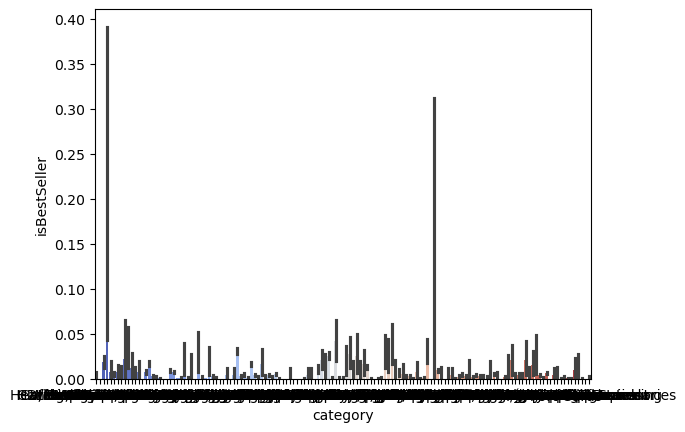

In [ ]:
sns.barplot(data=df , x='category', y='isBestSeller', palette="coolwarm")
plt.show()


PART 2

In [ ]:
# (Q1)
Q1 = df['price'].quantile(0.25)
Q1

np.float64(9.99)

In [ ]:
# (Q3)
Q3 = df['price'].quantile(0.75)

Q3

np.float64(45.0)

In [ ]:

IQR = Q3 - Q1
print("IQR:", IQR)  

IQR: 35.01


In [31]:
# Calculating the lower limit for outliers
lower_bound = Q1 - 1.5 * IQR
lower_bound 

np.float64(-42.525)

In [32]:
upper_bound = Q3 + 1.5 * IQR
upper_bound

np.float64(97.515)

In [41]:
# Filter the DataFrame to exclude outliers

df_filtered = df[
    (df['price'] >= lower_bound) & 
    (df['price'] <= upper_bound)
].copy()

df_filtered

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308.0,21.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099.0,23.99,True,0.0,Hi-Fi Speakers,NaN,NaN,NaN
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308.0,21.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205.0,31.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881.0,17.99,False,0.0,Hi-Fi Speakers,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1158202,B00XAA86ZS,Artdeco AD Rich Treatment Foundation Number 10...,4.2,30.0,14.97,False,0.0,Make-up,NaN,NaN,NaN
1048571,1158203,B00694W9NC,Black Opal Finishing Powder Neutral Light,4.4,135.0,16.17,False,0.0,Make-up,NaN,NaN,NaN
1048572,1158204,B0035LCW48,"Ardell Natural Style Eye Lashes Number 117, De...",3.9,35.0,5.49,False,0.0,Make-up,NaN,NaN,NaN
1048573,1158205,B001BKTHZM,"CLINIQUE Finishers, 0.5 Kg",0.0,0.0,36.33,False,0.0,Make-up,NaN,NaN,NaN


In [57]:
average_prices_by_category = df_filtered.groupby('category')['price'].mean()

# 2. Convertir la Series en DataFrame pour le tri et la sélection
average_prices_df = average_prices_by_category.reset_index()

# 3. Trier les prix moyens par ordre décroissant et sélectionner le top 10
top_10_average_prices = (
    average_prices_df.sort_values(by='price', ascending=False).head(10))
   
   
top_10_average_prices

,category,price
88,Motherboards,67.002857
47,Graphics Cards,61.809231
119,Skiing Poles,57.270657
26,Computer Cases,56.594940
79,Made in Italy Handmade,55.726140
73,Lab & Scientific Products,55.111071
98,"Motorbike Handlebars, Controls & Grips",53.400676
0,3D Printers,50.351562
4,Alexa Built-In Devices,50.171667
36,Dining Room Furniture,49.577941


In [50]:

top_10_prices = df_filtered.sort_values(by='price', ascending=False).head(10)
top_10_prices

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category,Unnamed: 9,Unnamed: 10,Unnamed: 11
324144,347020,B0C3NWZ2QZ,"1080P Wireless Video Projector, 1080P Home The...",0.0,0.0,97.51,False,0.0,Projectors,NaN,NaN,NaN
105194,113696,B07ZPFSNFB,Croove Karaoke Machine for Kids | Karoke Set w...,4.5,2067.0,97.51,False,0.0,Karaoke Equipment,NaN,NaN,NaN
691562,746095,B0CKDWNQ1Z,motorcycle hand guard Motorcycle Handguards Ha...,0.0,0.0,97.51,False,0.0,"Motorbike Handlebars, Controls & Grips",NaN,NaN,NaN
840345,915831,B0BBSXX3RP,MEGA Barbie The Movie Building Toys for Adults...,4.6,522.0,97.50,False,0.0,Dolls & Accessories,NaN,NaN,NaN
8895,9686,B0BTYFTY7B,EEEONE CDPro2 VAM1250 VAM1254 VAM1255 CD Pro 2...,0.0,0.0,97.50,False,0.0,"CD, Disc & Tape Players",NaN,NaN,NaN
732028,790390,B0C2HFZKB1,NICBEL Sports Smart Watch Women 1.47-inch Full...,0.0,0.0,97.50,False,0.0,Sports & Outdoors,NaN,NaN,NaN
732415,790796,B0C15BT3SH,QESTO KSD F35 Smart Watch Men Bluetooth Call C...,0.0,0.0,97.50,False,0.0,Sports & Outdoors,NaN,NaN,NaN
138699,150306,B097N51GTJ,Movino Glide Stunt Freestyle Scooter | 8 Years...,4.5,61.0,97.50,False,0.0,Sports & Outdoors,NaN,NaN,NaN
168120,180320,B00B8PRZRC,DIOR Miss Dior Eau de Toilette 100ml,4.6,247.0,97.50,False,0.0,Fragrances,NaN,NaN,NaN
742969,801651,B000SI1NZK,"BOSS Fv-500H High Impedance Volume Pedal, Ultr...",4.5,386.0,97.50,False,0.0,Guitars & Gear,NaN,NaN,NaN


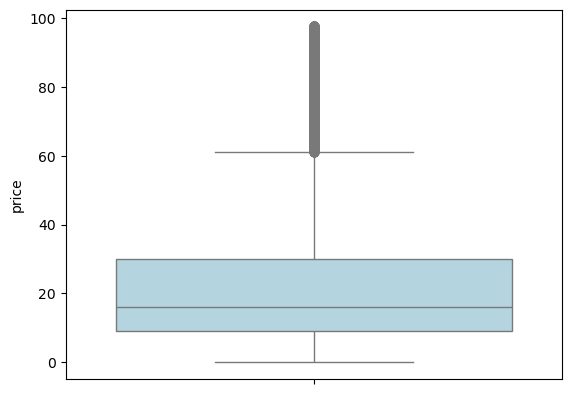

In [35]:
sns.boxplot(data = df_filtered['price'], color="lightblue")
plt.show()

C:\Users\mombo\AppData\Local\Temp\ipykernel_17976\3683670006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=top_10_prices, x='category', y='price', palette="coolwarm")


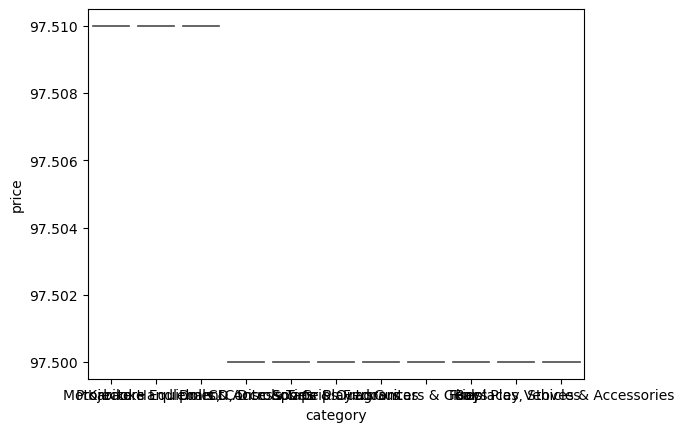

In [48]:
#2 

# Plotting a violin plot to visualize the distribution of 'SalePrice' for each 'MSZoning' category, using the "coolwarm" color palette
sns.violinplot(data=top_10_prices, x='category', y='price', palette="coolwarm")

plt.show()